In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv('spotify_hits.csv')

In [3]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [4]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

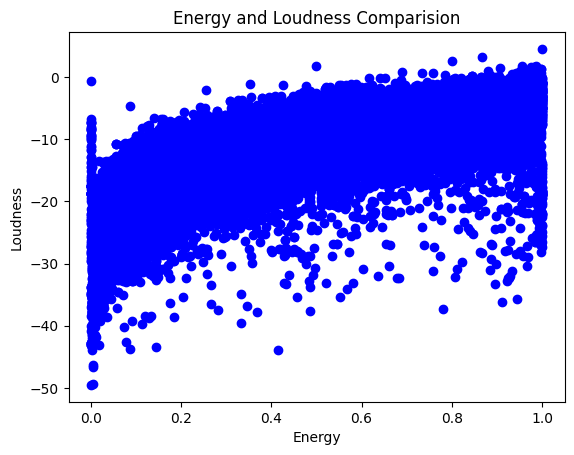

In [6]:
plt.scatter("energy","loudness", data=df , color = "blue")
plt.xlabel("Energy")
plt.ylabel("Loudness")
plt.title("Energy and Loudness Comparision")

plt.show()

1-) Target Variable Analysis: "What Makes a Song Popular?" (Correlation and Distribution)

Correlation Matrix (Heatmap)

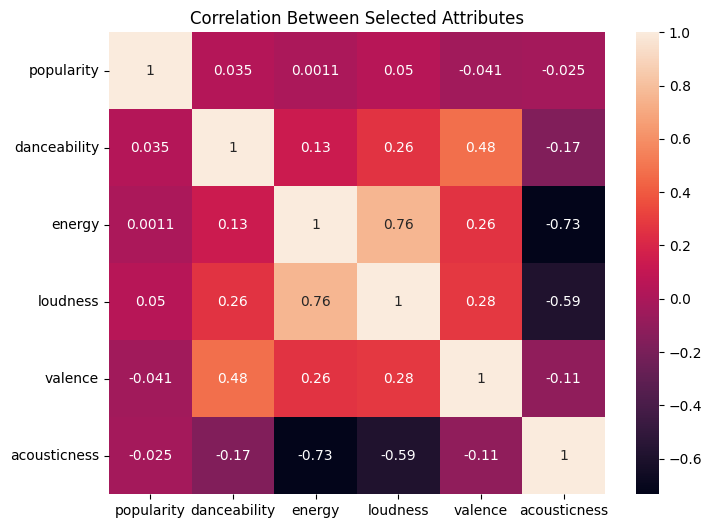

In [7]:
chosen_columns = ["popularity", "danceability", "energy", "loudness","valence","acousticness"]
corr_matrix = df[chosen_columns].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Between Selected Attributes")
plt.show()

Danceability and Popularity Graphs (Scatter and Hexbin)

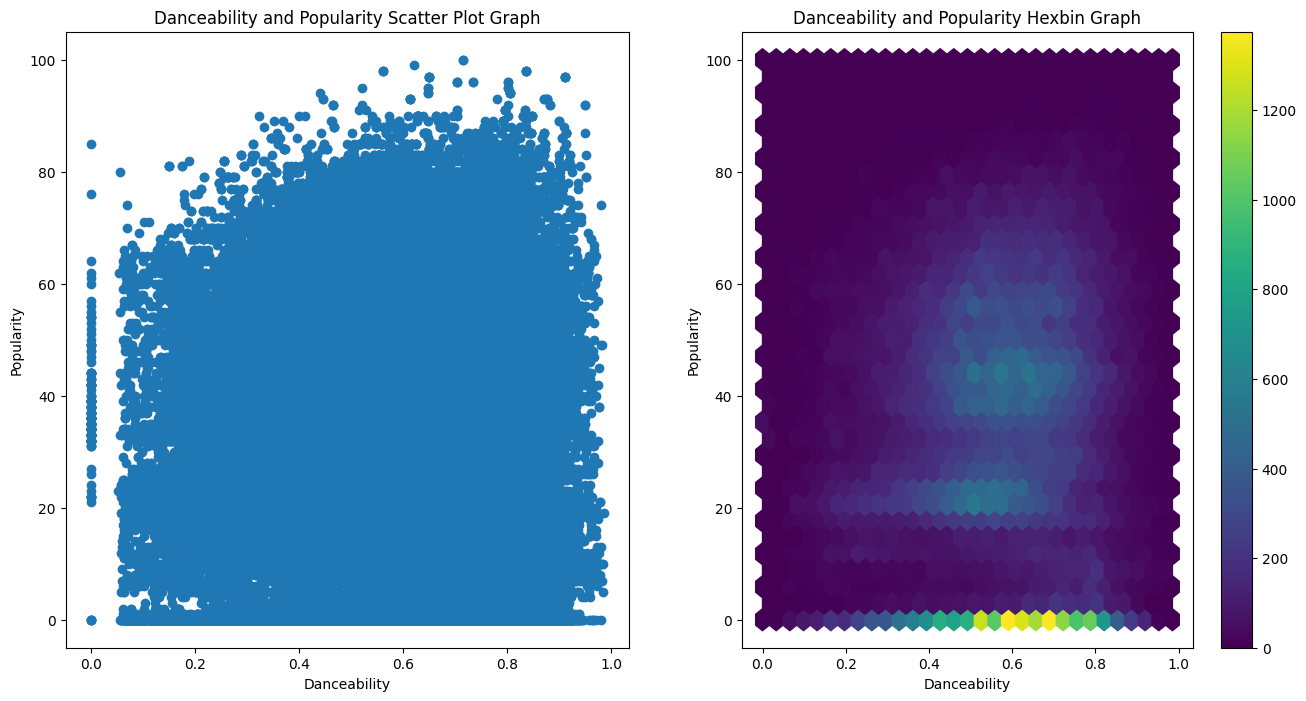

In [15]:
plt.figure(figsize=(16,8)) 

plt.subplot(1,2,1)
plt.scatter("danceability","popularity", data=df)
plt.xlabel("Danceability")
plt.ylabel("Popularity")
plt.title("Danceability and Popularity Scatter Plot Graph")

plt.subplot(1,2,2)
plt.hexbin("danceability", "popularity", data=df, gridsize=30, cmap="viridis")
plt.xlabel("Danceability")
plt.ylabel("Popularity")
plt.title("Danceability and Popularity Hexbin Graph")
plt.colorbar()

plt.show()

Energy and Popularity Graphs (Scatter and Hexbin)

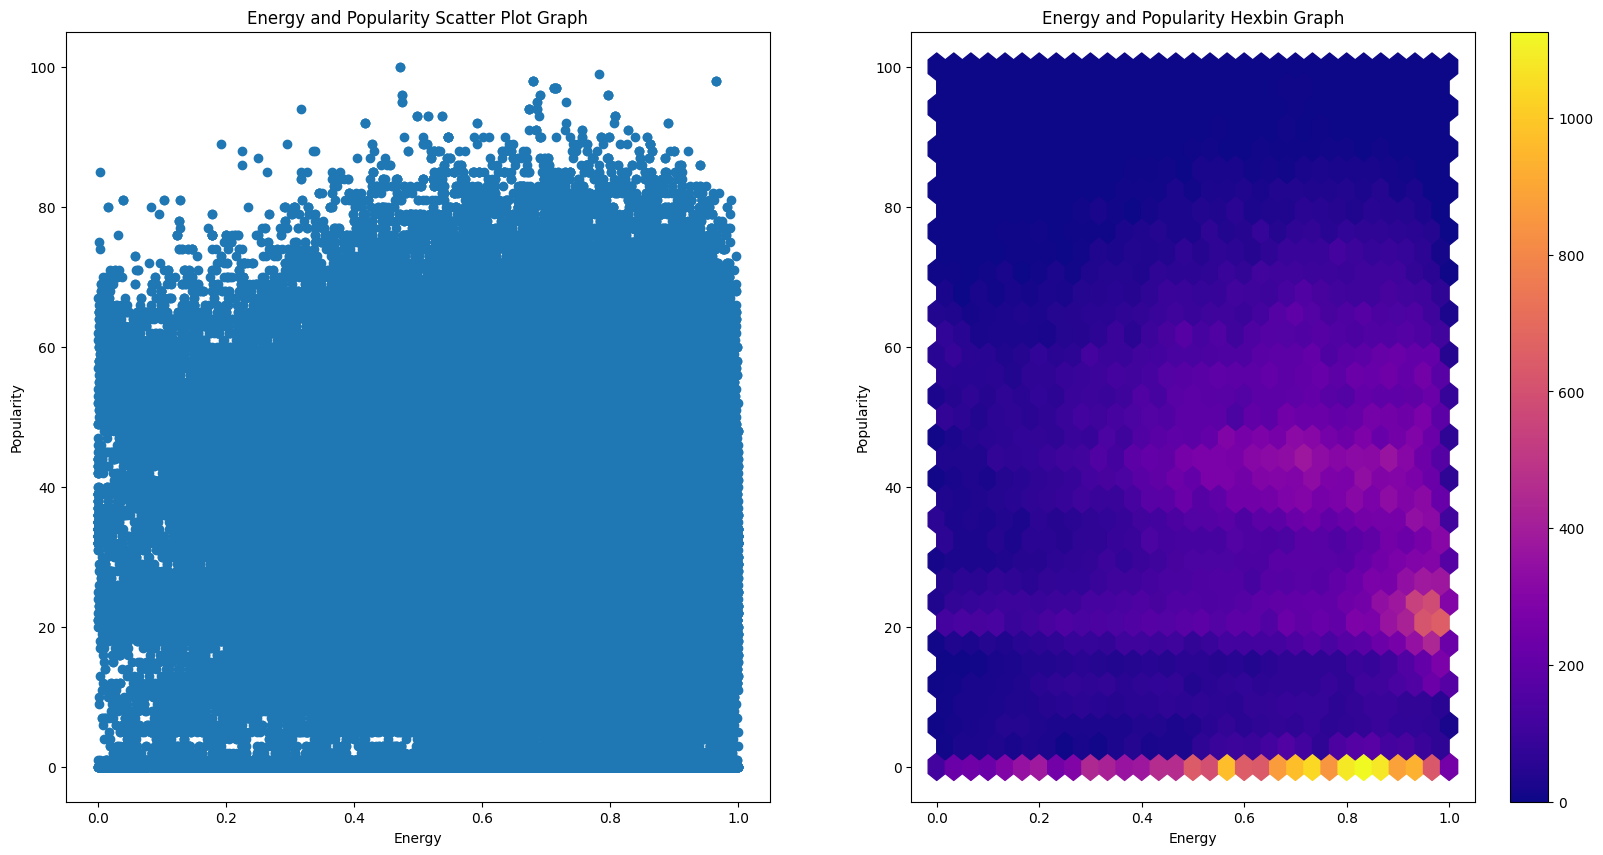

In [9]:
plt.figure(figsize=(20,10)) 

plt.subplot(1,2,1)
plt.scatter("energy","popularity", data=df)
plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.title("Energy and Popularity Scatter Plot Graph")

plt.subplot(1,2,2)
plt.hexbin("energy", "popularity", data=df, gridsize=30, cmap="plasma")
plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.title("Energy and Popularity Hexbin Graph")
plt.colorbar()

plt.show()

2-) Categorical Comparisons: "Character Analysis of Music Types"

The Most Popular 10 Music Types' Distribution Analysis of 'Valence and Tempo' with Box Plot and Violin Plot

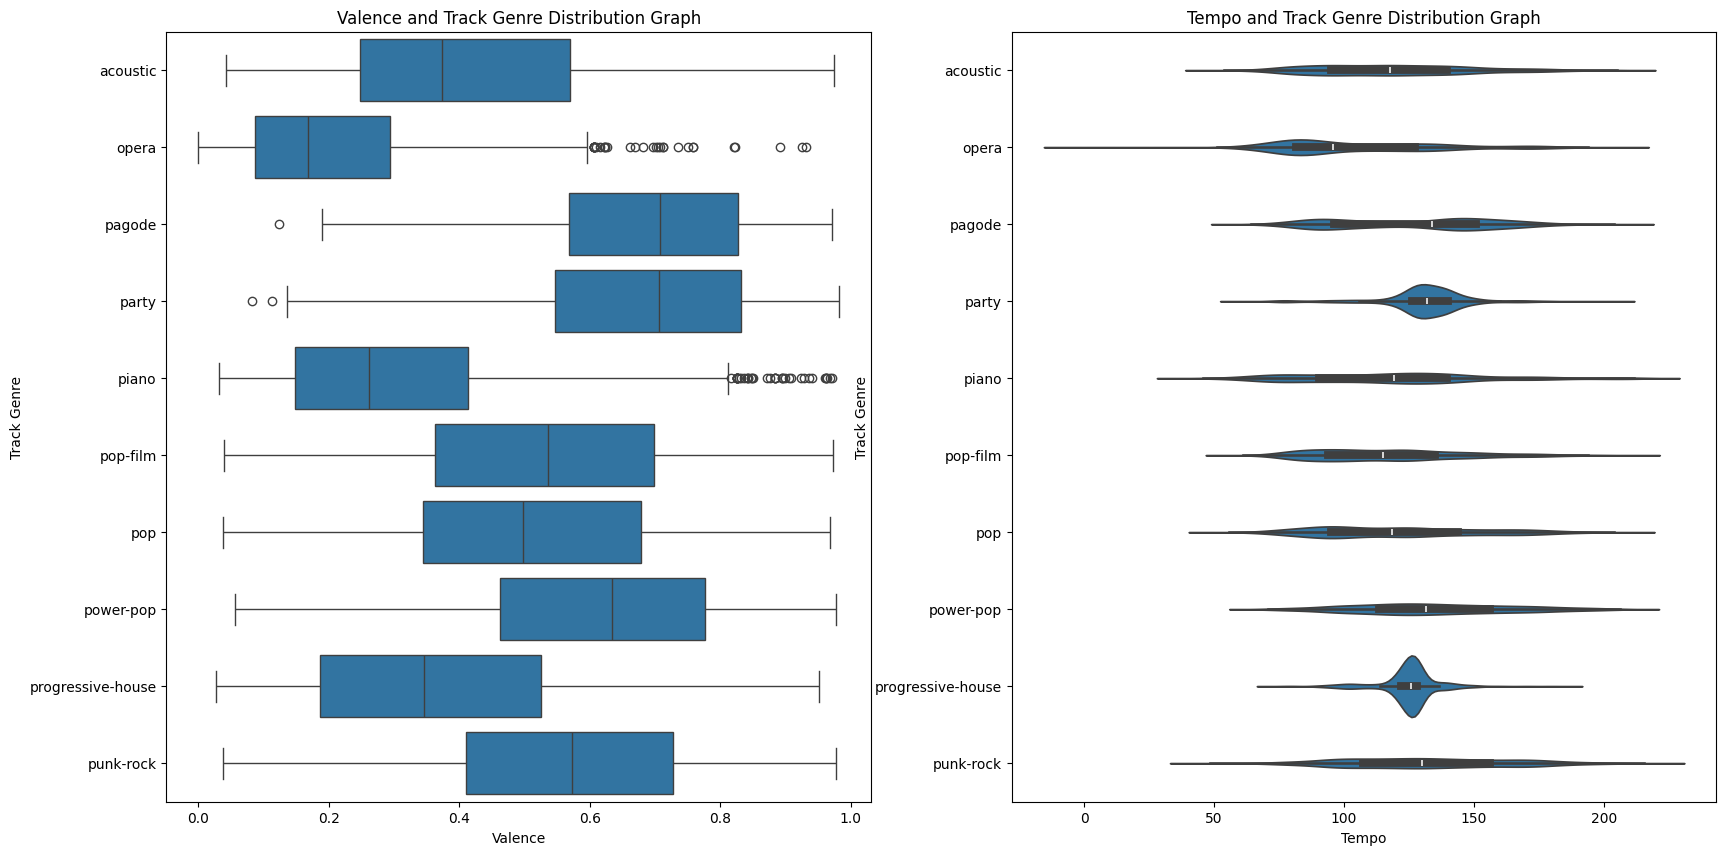

In [10]:
plt.figure(figsize=(20,10))
most_popular_ten_type  = df['track_genre'].value_counts().head(10).index
df_filtered = df[df['track_genre'].isin(most_popular_ten_type)]

plt.subplot(1,2,1)

sns.boxplot(x="valence",y="track_genre",data=df_filtered)
plt.xlabel("Valence")
plt.ylabel("Track Genre")
plt.title("Valence and Track Genre Distribution Graph")

plt.subplot(1,2,2)
sns.violinplot(x="tempo",y="track_genre",data=df_filtered)
plt.xlabel("Tempo")
plt.ylabel("Track Genre")
plt.title("Tempo and Track Genre Distribution Graph")

plt.show()

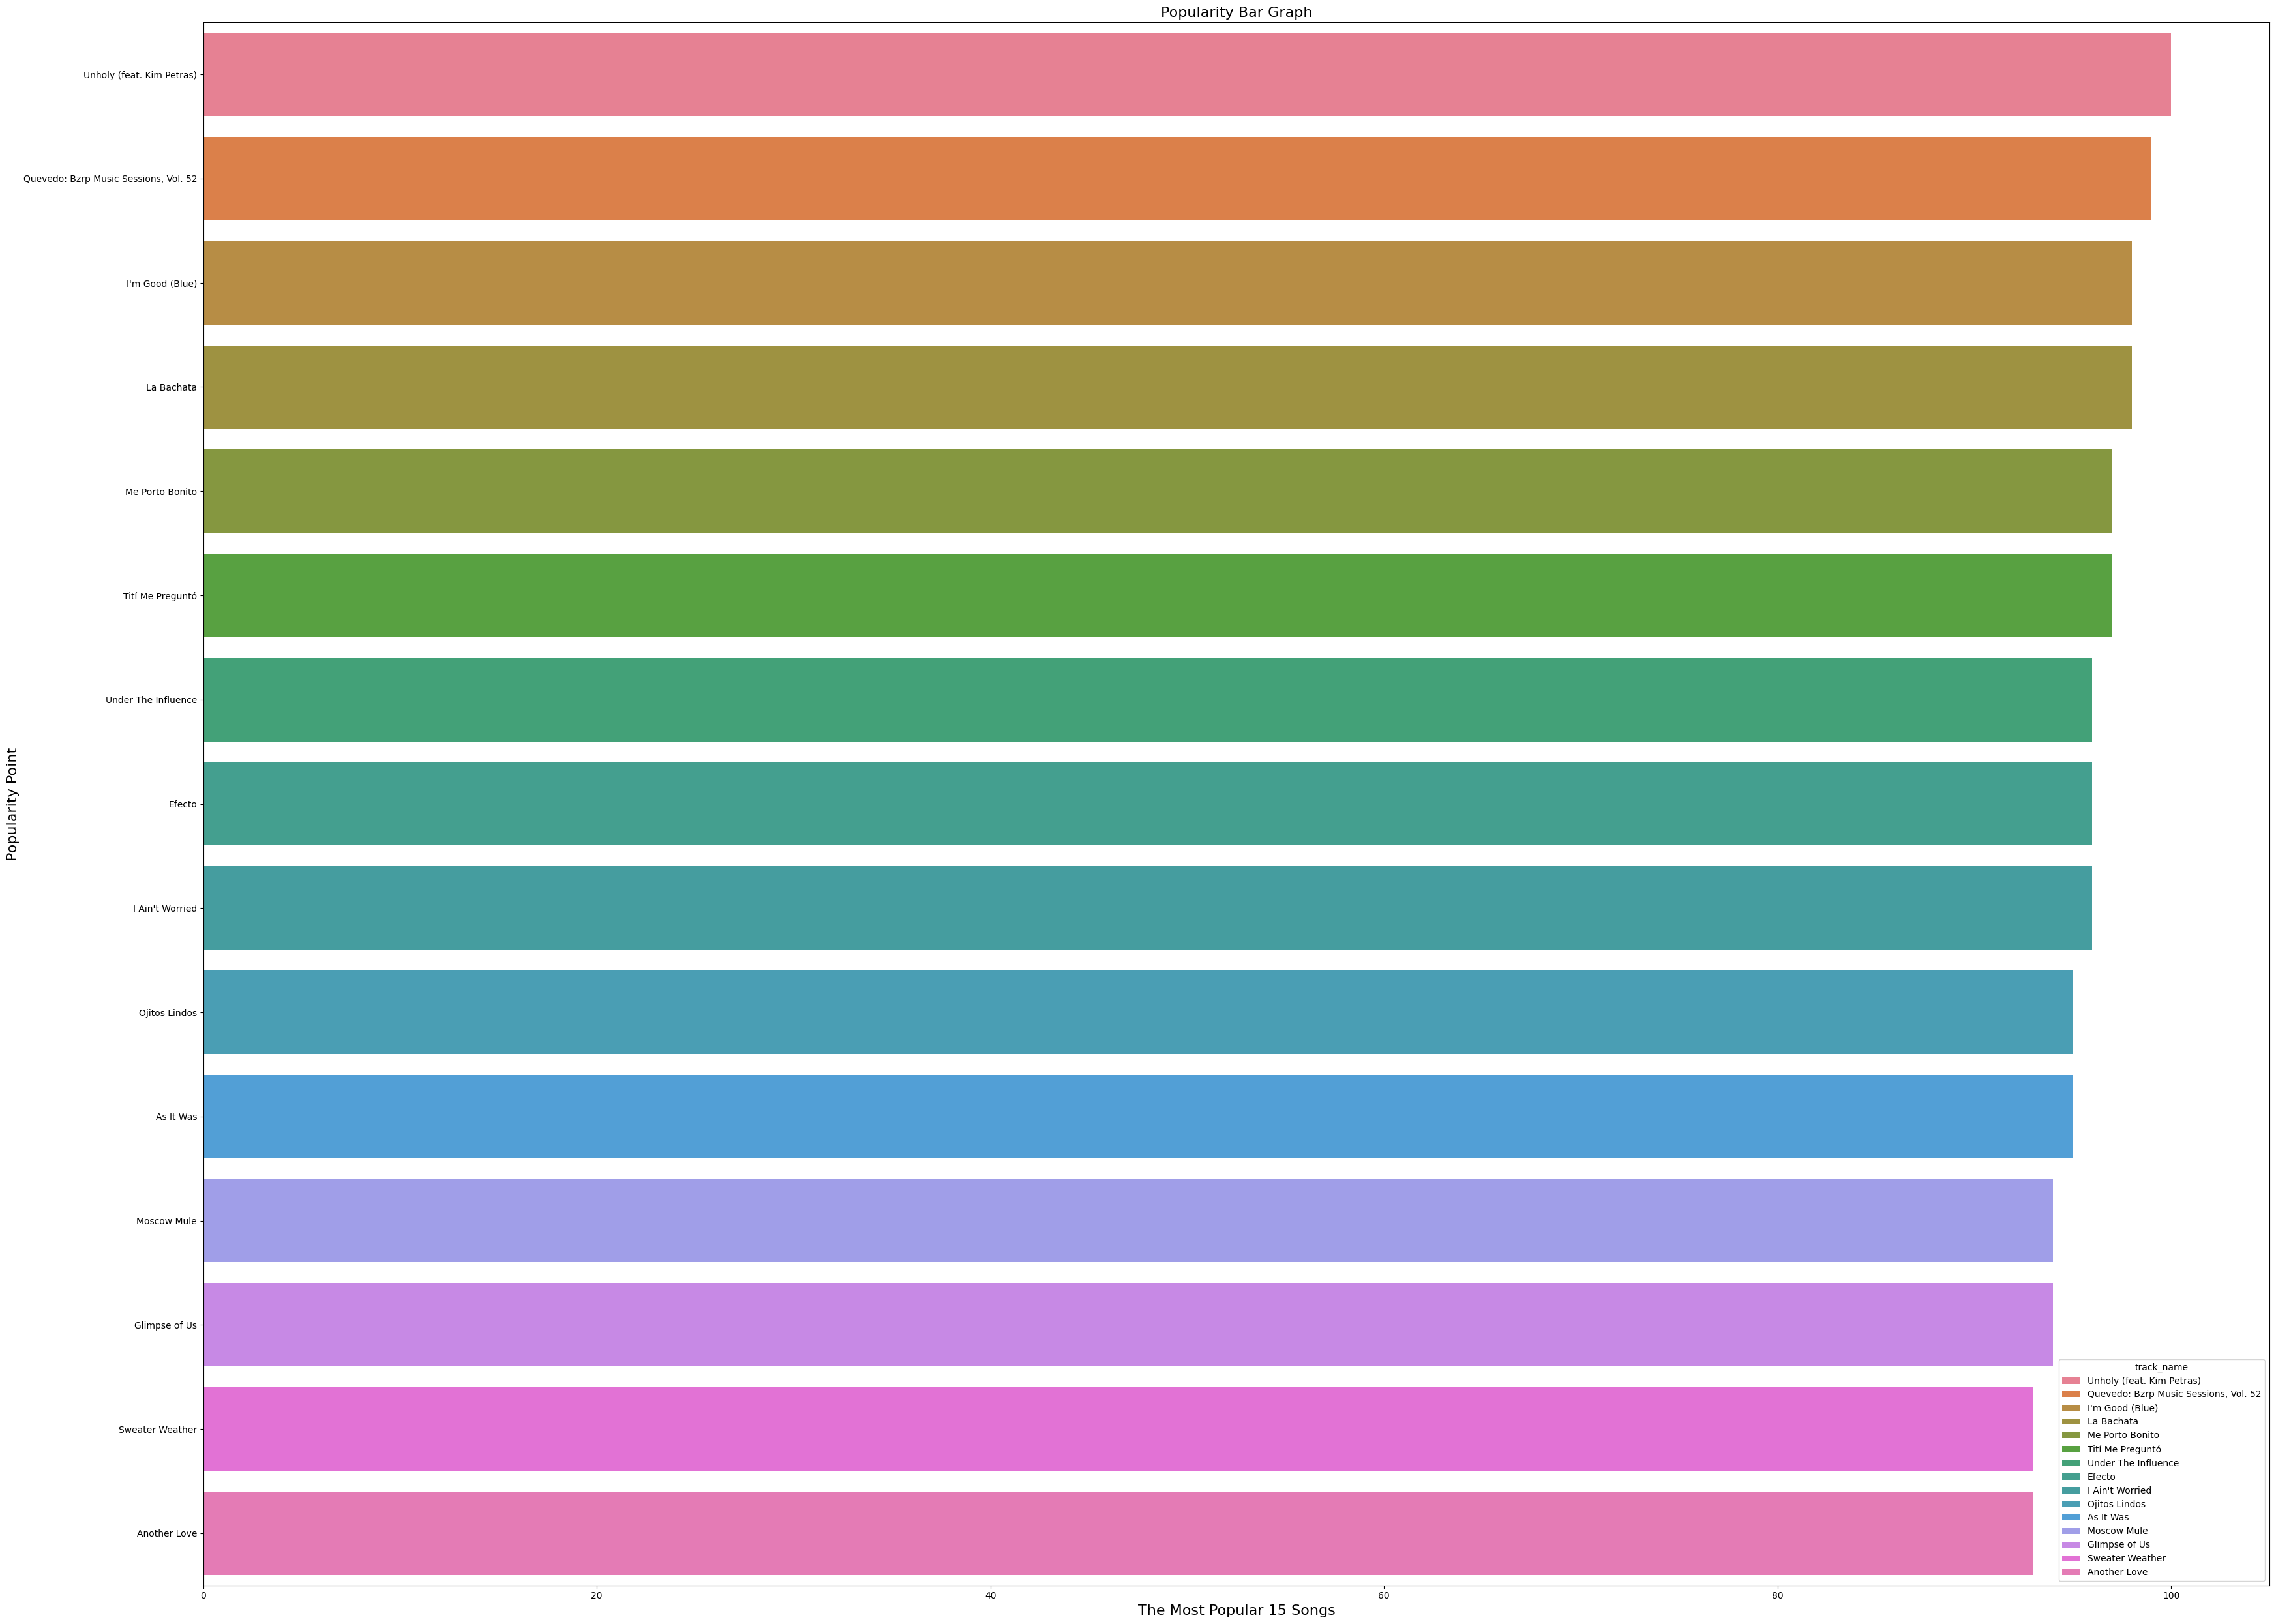

In [11]:
df_clean = df.drop_duplicates(subset=('track_name','artists'))

top_15_songs = df_clean.nlargest(15, 'popularity')

plt.figure(figsize=(35,25))
sns.barplot(x="popularity", y="track_name", data=top_15_songs, palette="husl", hue="track_name", legend=True)
plt.title("Popularity Bar Graph", fontsize = 16)
plt.xlabel("The Most Popular 15 Songs" , fontsize = 16)
plt.ylabel("Popularity Point", fontsize = 16)
plt.tight_layout()
plt.show()

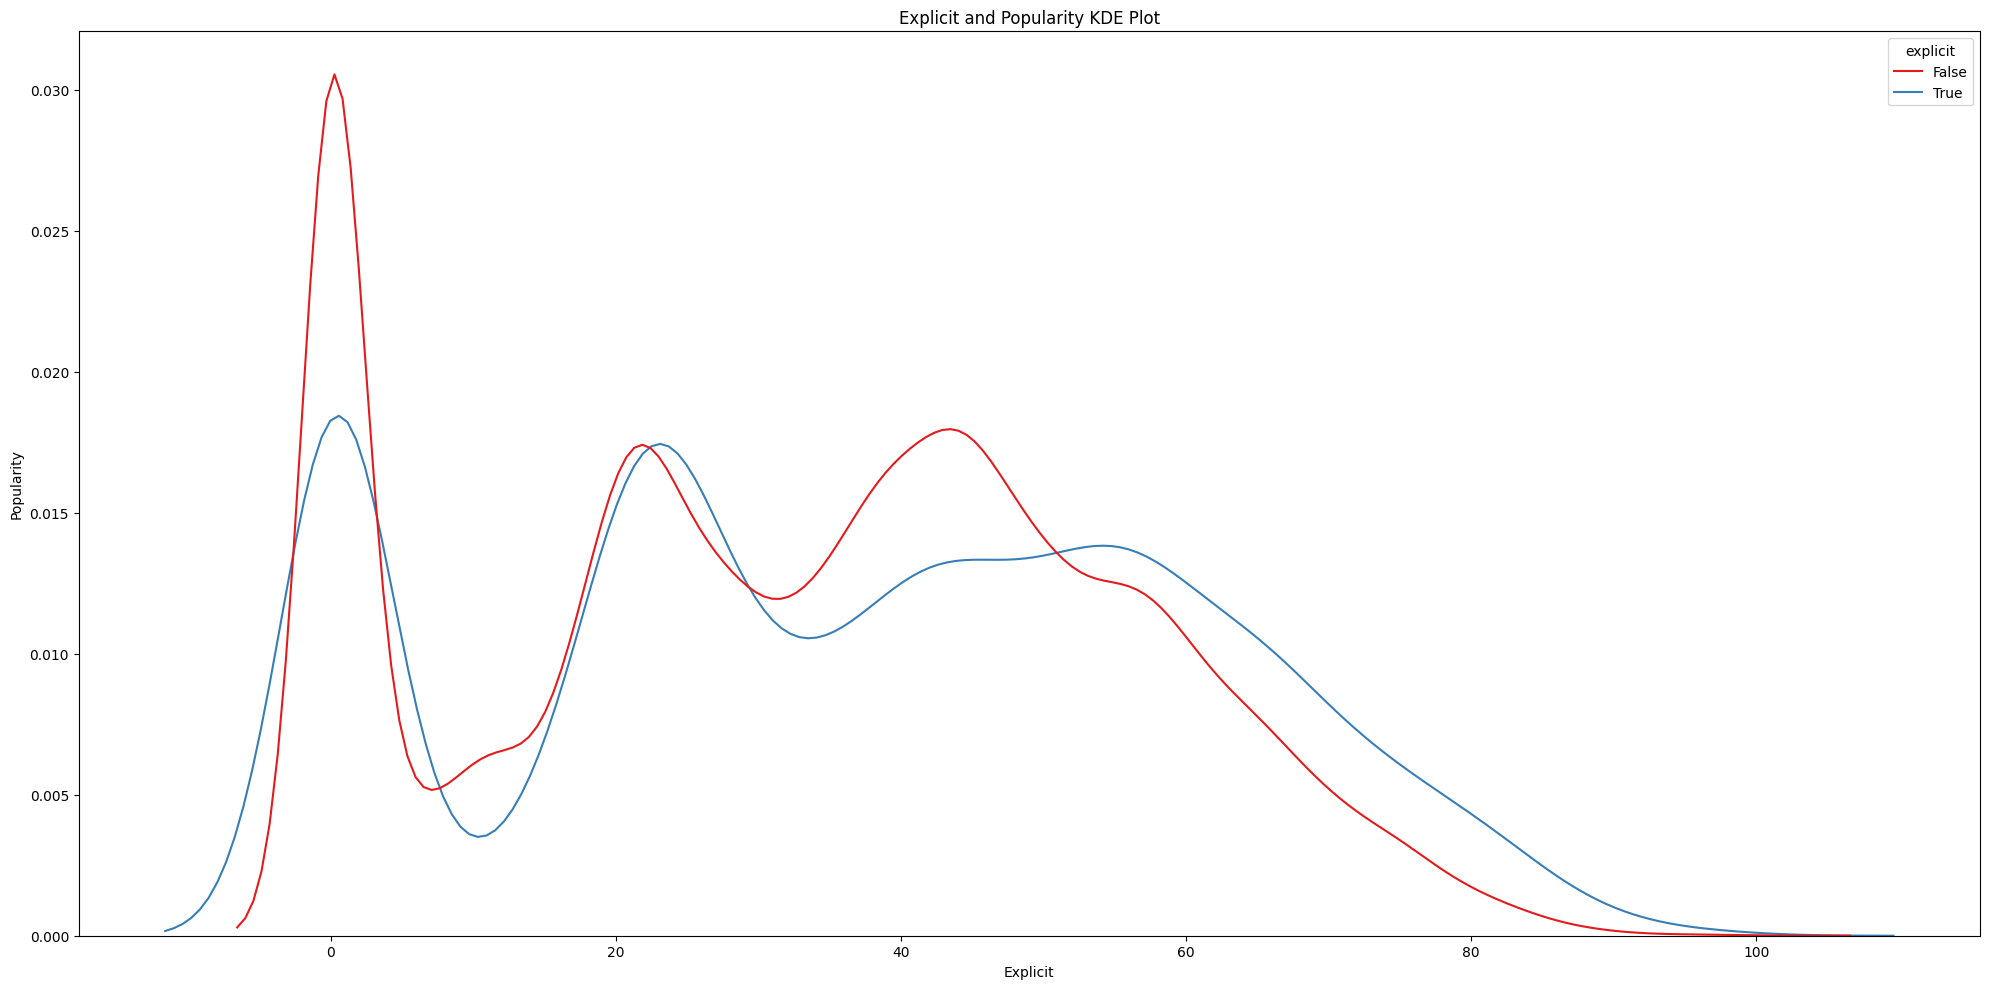

In [12]:
plt.figure(figsize=(20,10))
sns.kdeplot(hue = "explicit", x=  "popularity" , data = df, common_norm=False , palette = "Set1")
plt.xlabel("Explicit")
plt.ylabel("Popularity")
plt.title("Explicit and Popularity KDE Plot")
plt.tight_layout()
plt.show() 

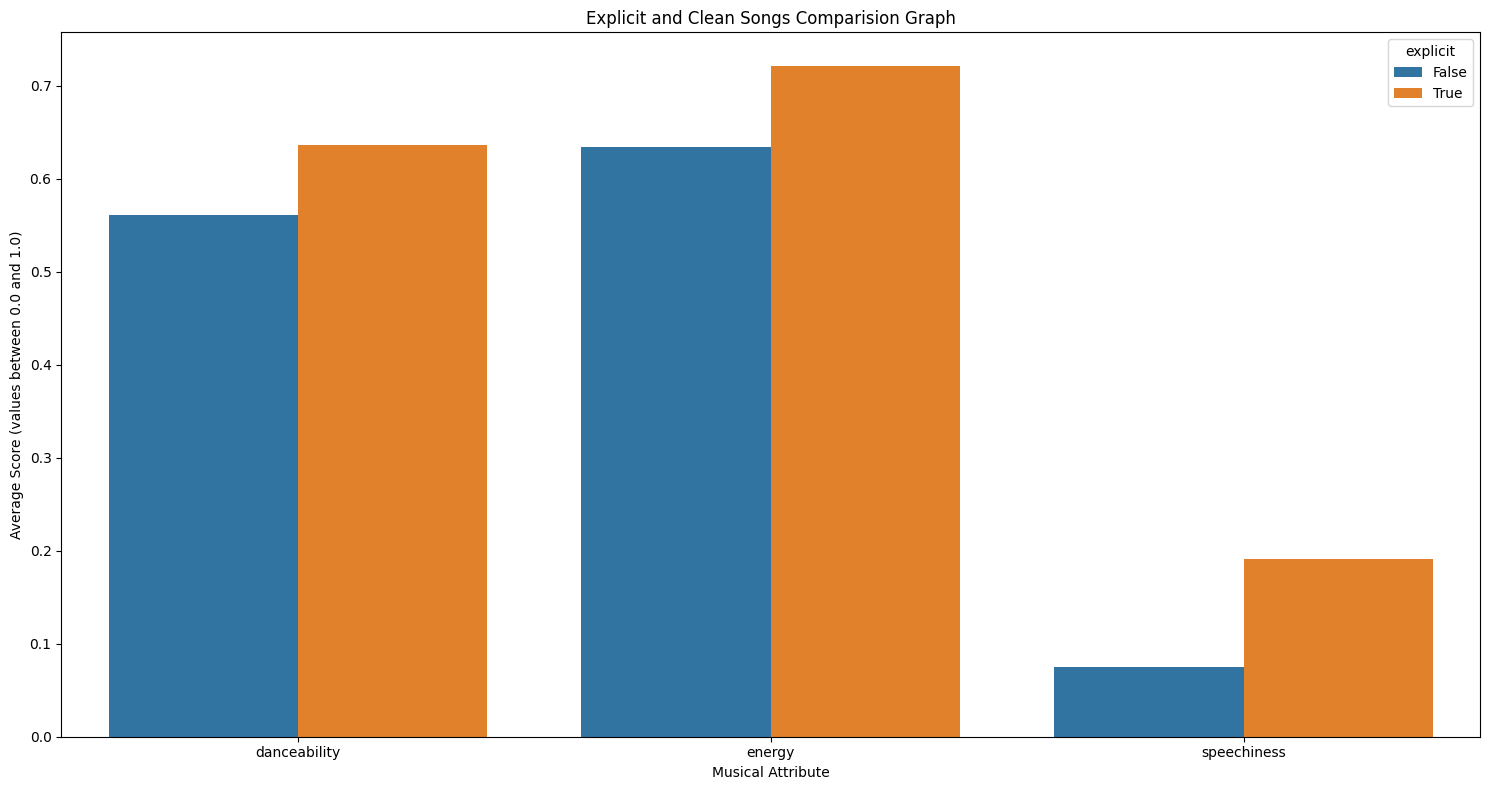

In [13]:
song_attributes = ['danceability','energy','speechiness']
average_values = df.groupby('explicit')[song_attributes].mean().reset_index()
melted_df = average_values.melt(id_vars = 'explicit', var_name = 'Musical Attributes', value_name='Average Values')

plt.figure(figsize=(15,8))

sns.barplot(x = "Musical Attributes", y = "Average Values", hue = "explicit", data = melted_df)
plt.title('Explicit and Clean Songs Comparision Graph')
plt.xlabel("Musical Attribute")
plt.ylabel("Average Score (values between 0.0 and 1.0)")

plt.tight_layout()
plt.show()


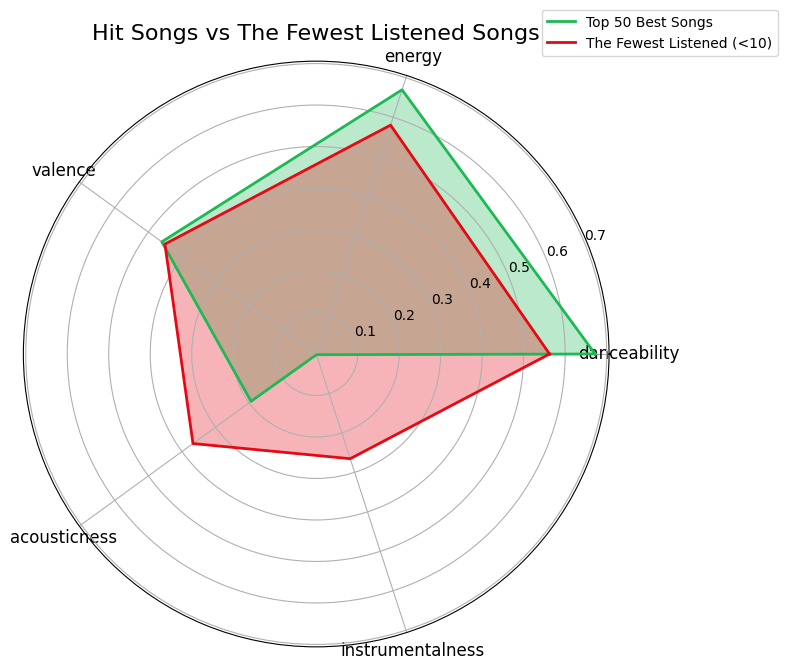

In [14]:
df_clean = df.drop_duplicates(subset=['track_name', 'artists'])

features = ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness']

top_50 = df_clean.nlargest(50, 'popularity') 
least_pop = df_clean[df_clean['popularity'] < 10] 


top_50_means = top_50[features].mean().tolist()
least_pop_means = least_pop[features].mean().tolist()


top_50_means += top_50_means[:1]
least_pop_means += least_pop_means[:1]


angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1] 


fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))


ax.plot(angles, top_50_means, color='#1DB954', linewidth=2, label='Top 50 Best Songs')
ax.fill(angles, top_50_means, color='#1DB954', alpha=0.3)


ax.plot(angles, least_pop_means, color='#E50914', linewidth=2, label='The Fewest Listened (<10)')
ax.fill(angles, least_pop_means, color='#E50914', alpha=0.3)


ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=12)

plt.title('Hit Songs vs The Fewest Listened Songs', fontsize=16)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()